<a href="https://colab.research.google.com/github/vxeyn/bayesiancompilation/blob/main/March_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#SAMPLE PYTHON CODE

from sklearn.linear_model import LinearRegression
import numpy as np

# Sample dataset
X = np.array([[1], [2], [3], [4], [5]])  # Independent variable
y = np.array([2, 4, 6, 8, 10])          # Dependent variable

# Create model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Predict new value
prediction = model.predict([[10]])

print("Prediction for input 10:", prediction)


Prediction for input 10: [20.]


In [ ]:
#GROUP SCRIPT
# Step 1: Import libraries

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
# Step 2: Load dataset

file_path = '/content/Medicine_Dataset.csv.xlsx'
df = pd.read_excel(file_path)

In [ ]:
# Step 3: Display first rows

print(df.head())

   Id  Age  Gender  Paracetamol  Acitaminophen  Aspirin  Ibuprofen  Tylenol  \
0   1   18    Male           80             30       80         50       50   
1   2   20  Female           60             20       70         40       40   
2   3   15    Male           20             40       50         60       20   
3   4   18  Female           50             30       60         30       30   
4   5   18    Male           30             25       28         34       37   

   Diphen  Bronkaid  ...  Aleve  Naproxen  Proprinal  Addaprin  Zebutal  \
0      60        40  ...     40        90         20        90       50   
1      20        30  ...     30        70         40        80       60   
2      70        50  ...     40        50         30        50       70   
3      50        60  ...     20        60         60        40       80   
4      40        80  ...     50        80         68        89       49   

   Meperdine  Abenol  Actiprofen  Vazalore  Year  
0         20      30   

In [ ]:
# Step 4: Remove missing values

df = df.dropna()

In [ ]:
# Step 5: Encode categorical variable (Gender)

encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])

In [ ]:
# Step 6: Remove ID column since it is not useful for clustering

X = df.drop(columns=['Id'])

In [ ]:
# Step 7: Standardize the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Step 8: Apply K-Means clustering

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
# Step 9: Add cluster labels to dataset

df['Cluster'] = clusters

In [ ]:
# Step 10: Reduce dimensions for visualization using PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

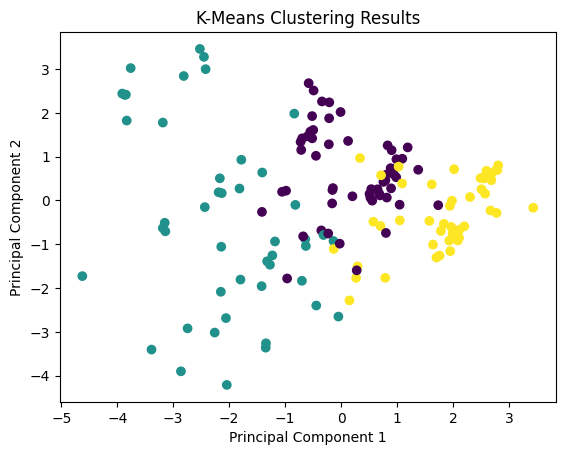

In [ ]:
# Step 11: Plot the clusters

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering Results')
plt.show()

In [ ]:
# Step 12: Show dataset with cluster labels

print(df.head())

   Id  Age  Gender  Paracetamol  Acitaminophen  Aspirin  Ibuprofen  Tylenol  \
0   1   18       1           80             30       80         50       50   
1   2   20       0           60             20       70         40       40   
2   3   15       1           20             40       50         60       20   
3   4   18       0           50             30       60         30       30   
4   5   18       1           30             25       28         34       37   

   Diphen  Bronkaid  ...  Naproxen  Proprinal  Addaprin  Zebutal  Meperdine  \
0      60        40  ...        90         20        90       50         20   
1      20        30  ...        70         40        80       60         30   
2      70        50  ...        50         30        50       70         50   
3      50        60  ...        60         60        40       80         40   
4      40        80  ...        80         68        89       49         19   

   Abenol  Actiprofen  Vazalore  Year  Cluster  
0